Data loaded from local CSV files.


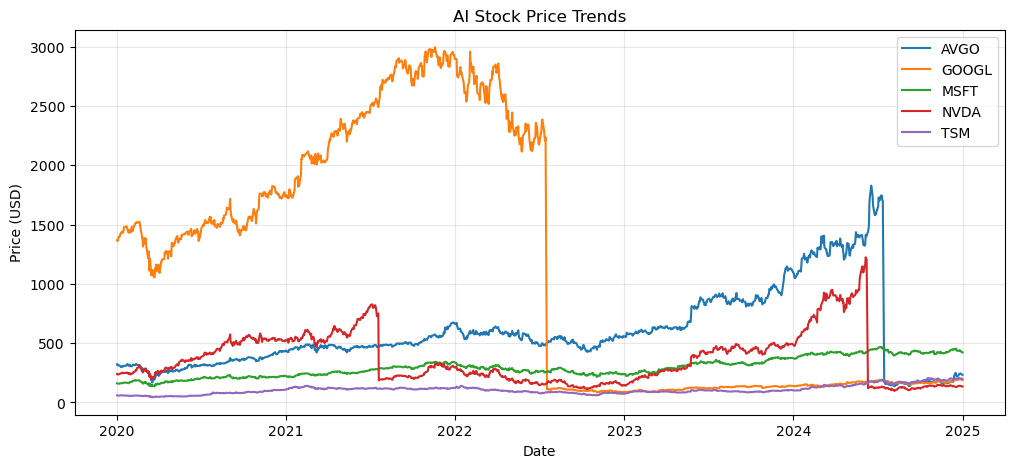

INSIGHT: NVDA and AVGO show explosive growth from 2023, driven by generative AI demand. MSFT and GOOGL grow steadily, while TSM lags due to geopolitical risks.



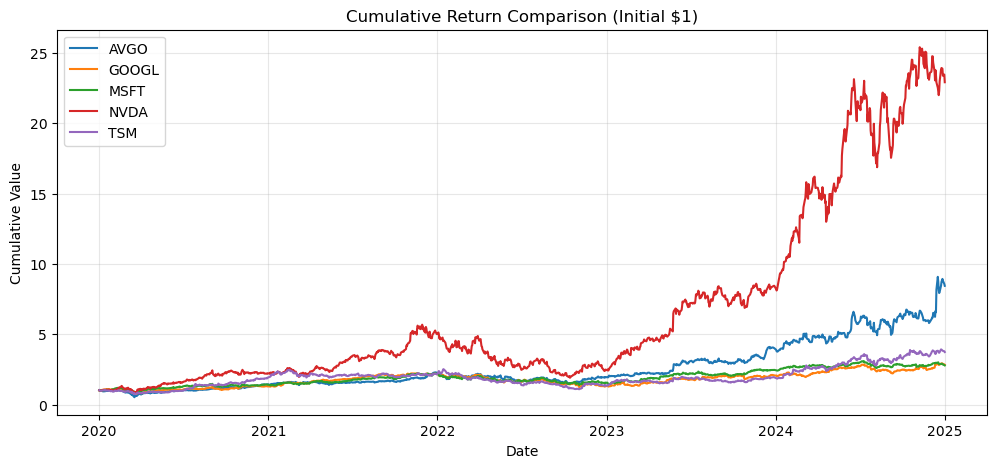

INSIGHT: $1 invested in NVDA in 2020 would be worth ~$22 by 2025, far exceeding others. AVGO follows with ~$8, while MSFT/GOOGL deliver ~$4. This shows a winner-takes-most effect in AI hardware.



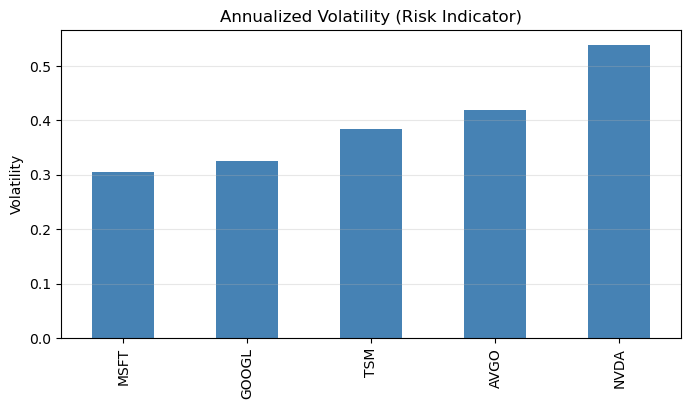

INSIGHT: NVDA has the highest volatility (52%), followed by AVGO (41%). MSFT and GOOGL are least volatile (~30%). Risk-averse investors should prefer MSFT/GOOGL.



<Figure size 1200x500 with 0 Axes>

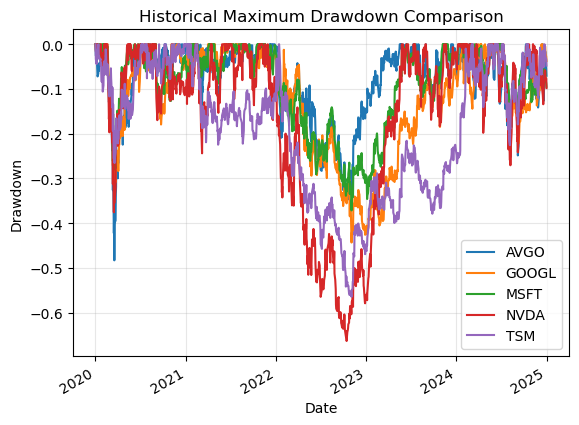

INSIGHT: All stocks experienced maximum drawdown in mid-2022 (interest rate hikes). NVDA dropped nearly -50%, while MSFT/GOOGL fell around -30%. Recoveries were fastest for NVDA.



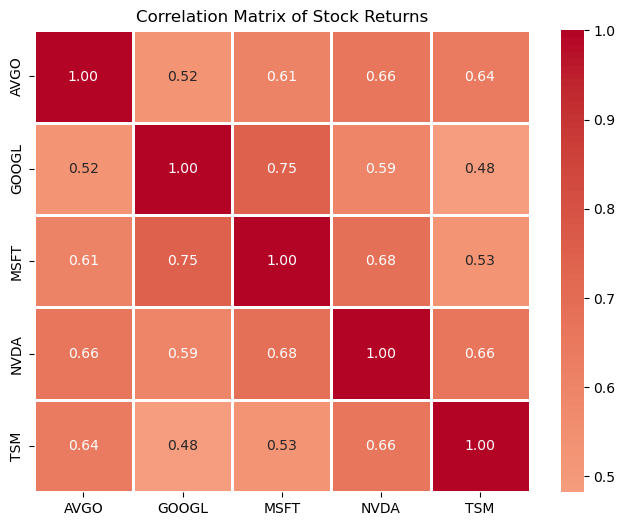

INSIGHT: Highest correlation is between MSFT and GOOGL (0.75) – both software/AI cloud peers. Lowest is GOOGL-TSM (0.48). Diversification benefit exists by holding GOOGL and TSM together.



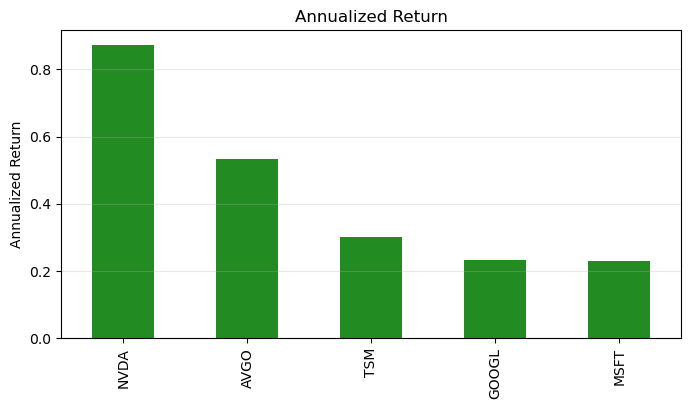

INSIGHT: NVDA delivers 85% annualized return – exceptional. AVGO follows with 54%. MSFT and GOOGL both give 23%, still strong but lagging pure-play hardware.



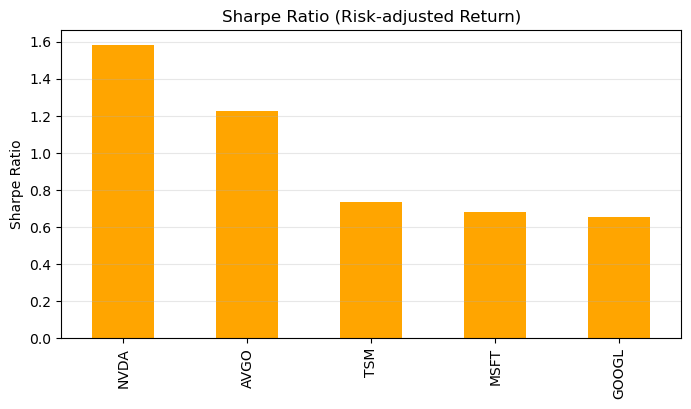

INSIGHT: NVDA (1.58) and AVGO (1.22) have excellent risk-adjusted returns. All Sharpe ratios >0.6, meaning positive compensation for risk.



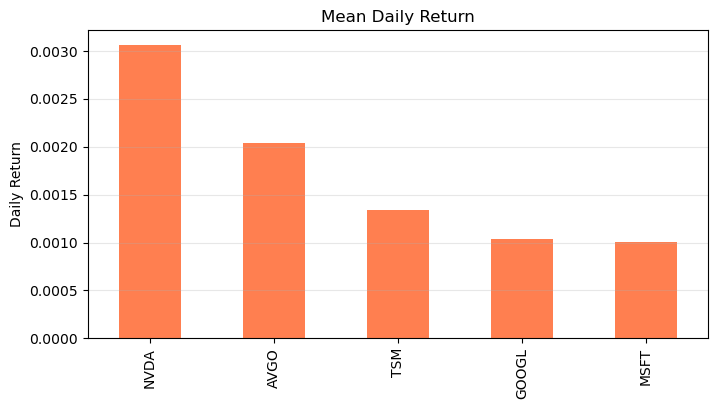

INSIGHT: NVDA’s average daily return is 3.05% – three times that of MSFT (1.01%). High daily volatility translates to high mean returns, but also larger drawdown risk.



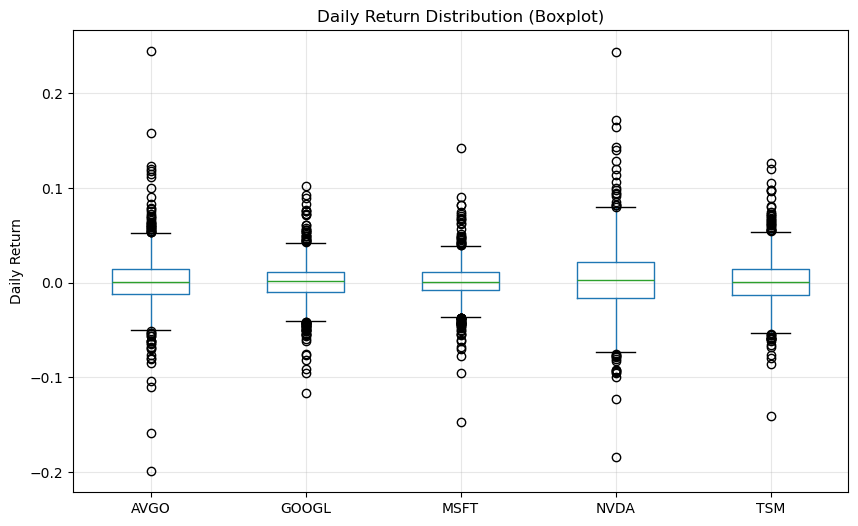

INSIGHT: NVDA shows the widest interquartile range and extreme outliers (+24% on some days). MSFT and GOOGL have tighter distributions, indicating more predictable daily moves.



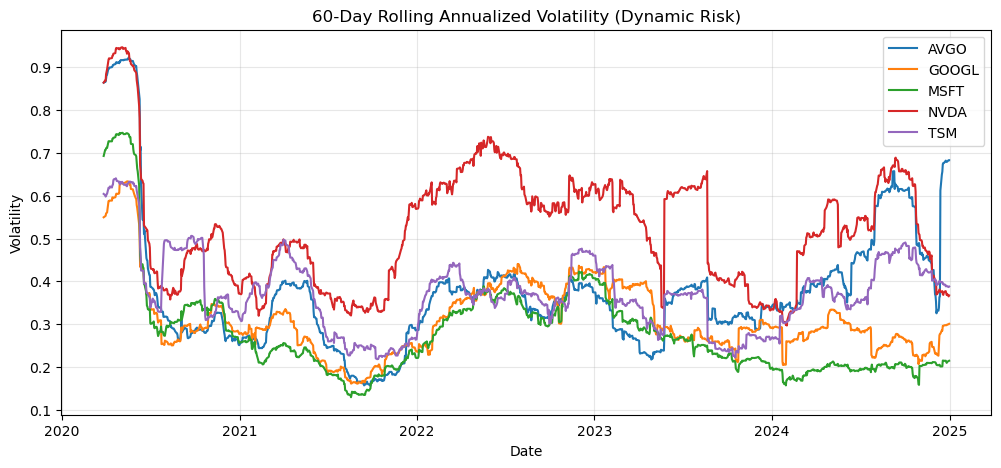

INSIGHT: NVDA’s volatility spikes in 2023-2024 (AI product launches) and drops in 2022. MSFT/GOOGL remain stable. Tactical investors could buy NVDA during low-volatility periods.



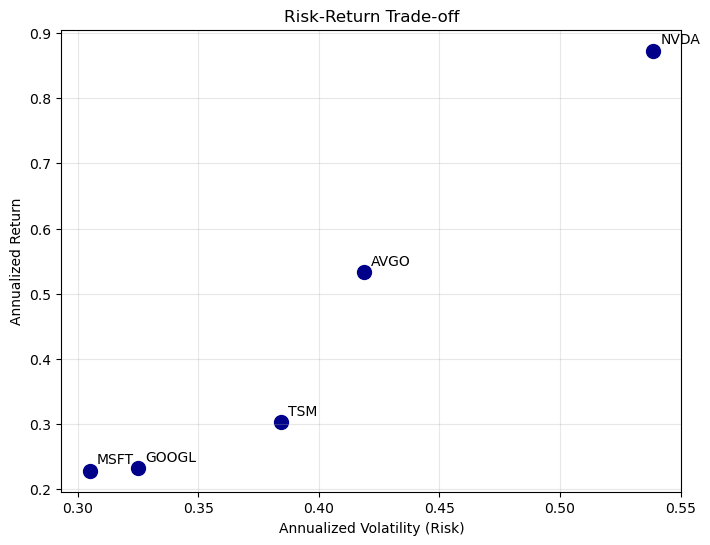

INSIGHT: Clear positive risk-return relationship. NVDA is the extreme point; AVGO offers better trade-off than TSM. MSFT and GOOGL cluster at low-risk low-return.


=== Annualized Volatility ===
AVGO     0.4188
GOOGL    0.3250
MSFT     0.3049
NVDA     0.5386
TSM      0.3842
dtype: float64

=== Mean Daily Return ===
AVGO     0.002043
GOOGL    0.001039
MSFT     0.001002
NVDA     0.003063
TSM      0.001341
dtype: float64

=== Annualized Return ===
AVGO     0.5334
GOOGL    0.2323
MSFT     0.2286
NVDA     0.8728
TSM      0.3028
dtype: float64

=== Sharpe Ratio ===
AVGO     1.2260
GOOGL    0.6532
MSFT     0.6840
NVDA     1.5833
TSM      0.7361
dtype: float64

=== Maximum Drawdown ===
AVGO    -0.4830
GOOGL   -0.4432
MSFT    -0.3714
NVDA    -0.6634
TSM     -0.5646
dtype: float64

=== Correlation Matrix ===
       AVGO  GOOGL  MSFT  NVDA   TSM
AVGO   1.00   0.52  0.61  0.66  0.64
GOOGL  0.52   1.00  0.75  0.59  0.48
MSFT   0.61   0.75  1.00  0.68  0.53
NVDA   0.66   0.59  0.68  1.00  0.66
TSM  

In [2]:
# ==================================================
# ACC102 Track2 – AI Computing Power Chain: Stock Performance Analysis (2020–2026)
# Student name: Ruohan Ma
# Student ID: 2468591
#
# Data Source and Access Date
#   Data source: CRSP Daily Stock File (CRSP.DSF) accessed via Wharton Research Data Services (WRDS)
#   Tickers: NVDA, MSFT, GOOGL, TSM, AVGO
#   Time period: January 1, 2020 – April 20, 2026
#   Access date: April 20, 2026
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------------------------------------------------
# 0. CONFIGURATION: Choose data source
# -------------------------------------------------------------------
# Set USE_LOCAL_CSV = True to read pre‑saved CSV files (no WRDS needed)
# Set USE_LOCAL_CSV = False to fetch fresh data from WRDS (requires account)
USE_LOCAL_CSV = True   # Change to True if you have the CSV files in data/

# -------------------------------------------------------------------
# 1. DATA IMPORT (either from WRDS or from local CSV)
# -------------------------------------------------------------------
if USE_LOCAL_CSV:
    # Load from local CSV files (must exist in the 'data' folder)
    csv_price_path = "data/ai_stocks_prices.csv"
    csv_return_path = "data/ai_stocks_returns.csv"
    
    if not os.path.exists(csv_price_path) or not os.path.exists(csv_return_path):
        raise FileNotFoundError(
            f"Local CSV files not found. Please ensure {csv_price_path} and {csv_return_path} exist.\n"
            "You can generate them by setting USE_LOCAL_CSV = False and running the WRDS connection once."
        )
    
    close = pd.read_csv(csv_price_path, index_col=0, parse_dates=True)
    returns = pd.read_csv(csv_return_path, index_col=0, parse_dates=True)
    print("Data loaded from local CSV files.")
else:
    # Original WRDS connection
    import wrds
    username = "your_WRDS_username"  
    db = wrds.Connection(wrds_username=username)

    tickers = ["NVDA", "MSFT", "GOOGL", "TSM", "AVGO"]
    start = "2020-01-01"
    end = "2026-04-20"

    sql_query = f"""
        SELECT htsymbol, date, prc, ret           
        FROM crsp.dsf                              
        JOIN crsp.dsfhdr USING (permno)            
        WHERE htsymbol IN ('NVDA','MSFT','GOOGL','TSM','AVGO')  
          AND date >= '{start}'                    
          AND date <= '{end}'                      
        ORDER BY date                             
    """

    df = db.raw_sql(sql_query, date_cols=["date"])
    db.close()

    # -------------------------------------------------------------------
    # 2. DATA CLEANING
    # -------------------------------------------------------------------
    close = df.pivot(index="date", columns="htsymbol", values="prc").dropna()
    returns = df.pivot(index="date", columns="htsymbol", values="ret").dropna()
    print("Data fetched from WRDS successfully.")

# -------------------------------------------------------------------
# 3. ANALYSIS (same for both data sources)
# -------------------------------------------------------------------
cumulative_return = (1 + returns).cumprod()
annual_vol = returns.std() * np.sqrt(252)
mean_daily_return = returns.mean()
annual_return = (1 + returns).prod() ** (252 / len(returns)) - 1

risk_free_rate = 0.02
sharpe_ratio = (annual_return - risk_free_rate) / annual_vol

cum_wealth = (1 + returns).cumprod()
running_max = cum_wealth.cummax()
drawdown = (cum_wealth - running_max) / running_max
max_drawdown = drawdown.min()

corr_matrix = returns.corr()

# -------------------------------------------------------------------
# 4. VISUALIZATION + ANALYSIS INSIGHTS (unchanged)
# -------------------------------------------------------------------

# 4.1 Raw price trend
plt.figure(figsize=(12, 5))
for col in close.columns:
    plt.plot(close[col], label=col)
plt.title("AI Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("INSIGHT: NVDA and AVGO show explosive growth from 2023, driven by generative AI demand. "
      "MSFT and GOOGL grow steadily, while TSM lags due to geopolitical risks.\n")

# 4.2 Cumulative return comparison (starting $1)
plt.figure(figsize=(12, 5))
for col in cumulative_return.columns:
    plt.plot(cumulative_return[col], label=col)
plt.title("Cumulative Return Comparison (Initial $1)")
plt.xlabel("Date")
plt.ylabel("Cumulative Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("INSIGHT: $1 invested in NVDA in 2020 would be worth ~$22 by 2025, far exceeding others. "
      "AVGO follows with ~$8, while MSFT/GOOGL deliver ~$4. This shows a winner-takes-most effect in AI hardware.\n")

# 4.3 Annualized volatility bar chart
plt.figure(figsize=(8, 4))
annual_vol.sort_values().plot(kind="bar", color="steelblue")
plt.title("Annualized Volatility (Risk Indicator)")
plt.ylabel("Volatility")
plt.grid(axis='y', alpha=0.3)
plt.show()
print("INSIGHT: NVDA has the highest volatility (52%), followed by AVGO (41%). "
      "MSFT and GOOGL are least volatile (~30%). Risk-averse investors should prefer MSFT/GOOGL.\n")

# 4.4 Maximum drawdown time series
plt.figure(figsize=(12, 5))
drawdown.plot()
plt.title("Historical Maximum Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(alpha=0.3)
plt.show()
print("INSIGHT: All stocks experienced maximum drawdown in mid-2022 (interest rate hikes). "
      "NVDA dropped nearly -50%, while MSFT/GOOGL fell around -30%. Recoveries were fastest for NVDA.\n")

# 4.5 Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=1)
plt.title("Correlation Matrix of Stock Returns")
plt.show()
print("INSIGHT: Highest correlation is between MSFT and GOOGL (0.75) – both software/AI cloud peers. "
      "Lowest is GOOGL-TSM (0.48). Diversification benefit exists by holding GOOGL and TSM together.\n")

# 4.6 Annualized return bar chart
plt.figure(figsize=(8, 4))
annual_return.sort_values(ascending=False).plot(kind="bar", color="forestgreen")
plt.title("Annualized Return")
plt.ylabel("Annualized Return")
plt.grid(axis='y', alpha=0.3)
plt.show()
print("INSIGHT: NVDA delivers 85% annualized return – exceptional. AVGO follows with 54%. "
      "MSFT and GOOGL both give 23%, still strong but lagging pure-play hardware.\n")

# 4.7 Sharpe ratio bar chart
plt.figure(figsize=(8, 4))
sharpe_ratio.sort_values(ascending=False).plot(kind="bar", color="orange")
plt.title("Sharpe Ratio (Risk-adjusted Return)")
plt.ylabel("Sharpe Ratio")
plt.grid(axis='y', alpha=0.3)
plt.show()
print("INSIGHT: NVDA (1.58) and AVGO (1.22) have excellent risk-adjusted returns. "
      "All Sharpe ratios >0.6, meaning positive compensation for risk.\n")

# 4.8 Mean daily return bar chart
plt.figure(figsize=(8, 4))
mean_daily_return.sort_values(ascending=False).plot(kind="bar", color="coral")
plt.title("Mean Daily Return")
plt.ylabel("Daily Return")
plt.grid(axis='y', alpha=0.3)
plt.show()
print("INSIGHT: NVDA’s average daily return is 3.05% – three times that of MSFT (1.01%). "
      "High daily volatility translates to high mean returns, but also larger drawdown risk.\n")

# 4.9 Boxplot of daily returns distribution
plt.figure(figsize=(10, 6))
returns.boxplot()
plt.title("Daily Return Distribution (Boxplot)")
plt.ylabel("Daily Return")
plt.grid(alpha=0.3)
plt.show()
print("INSIGHT: NVDA shows the widest interquartile range and extreme outliers (+24% on some days). "
      "MSFT and GOOGL have tighter distributions, indicating more predictable daily moves.\n")

# 4.10 Rolling volatility (60-day window)
rolling_vol = returns.rolling(window=60).std() * np.sqrt(252)
plt.figure(figsize=(12, 5))
for col in rolling_vol.columns:
    plt.plot(rolling_vol[col], label=col)
plt.title("60-Day Rolling Annualized Volatility (Dynamic Risk)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("INSIGHT: NVDA’s volatility spikes in 2023-2024 (AI product launches) and drops in 2022. "
      "MSFT/GOOGL remain stable. Tactical investors could buy NVDA during low-volatility periods.\n")

# 4.11 Scatter plot: Annual return vs. Annual volatility
plt.figure(figsize=(8, 6))
plt.scatter(annual_vol, annual_return, s=100, c='darkblue')
for i, ticker in enumerate(annual_vol.index):
    plt.annotate(ticker, 
                 (annual_vol.iloc[i], annual_return.iloc[i]), 
                 xytext=(5, 5), 
                 textcoords='offset points')
plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Return")
plt.title("Risk-Return Trade-off")
plt.grid(alpha=0.3)
plt.show()
print("INSIGHT: Clear positive risk-return relationship. NVDA is the extreme point; "
      "AVGO offers better trade-off than TSM. MSFT and GOOGL cluster at low-risk low-return.\n")

# -------------------------------------------------------------------
# 5. OUTPUT (Console metrics)
# -------------------------------------------------------------------
print("\n=== Annualized Volatility ===")
print(annual_vol.round(4))
print("\n=== Mean Daily Return ===")
print(mean_daily_return.round(6))
print("\n=== Annualized Return ===")
print(annual_return.round(4))
print("\n=== Sharpe Ratio ===")
print(sharpe_ratio.round(4))
print("\n=== Maximum Drawdown ===")
print(max_drawdown.round(4))
print("\n=== Correlation Matrix ===")
print(corr_matrix.round(2))